# CIFAR-10 Image Classification with CNN

**Dataset**: CIFAR-10 — 60,000 color images (32×32) across 10 classes  
**Architecture**: 3-layer CNN with BatchNormalization and Dropout  
**Techniques**: Data Augmentation, EarlyStopping, ReduceLROnPlateau  
**Final Test Accuracy**: **74.84%**

### Key Design Choices
- BatchNormalization after every Conv layer for training stability
- Progressive Dropout (0.25 → 0.5) to prevent overfitting
- On-the-fly data augmentation to improve generalization
- Adaptive learning rate scheduling to fine-tune near convergence

### Loading the necessary libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,models

### Loading the dataset

In [6]:
(training_images,training_labels),(testing_images,testing_labels) = datasets.cifar10.load_data()

### Normalizing the training and test data

In [7]:
training_images = training_images/255
testing_images  = testing_images/255

### Labels for the classnames

In [8]:
class_names = ['Planes','Car','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']


### Basic info of the dataset

In [26]:
def dataset_info(X_train, y_train, X_test, y_test):
    print("DATASET INFO")
    print(f"Train samples     : {X_train.shape[0]}")
    print(f"Test  samples     : {X_test.shape[0]}")
    print(f"Input shape       : {X_train.shape[1:]}")
    print(f"Data type         : {X_train.dtype}")
    print(f"Value range       : [{X_train.min()}, {X_train.max()}]")
    print(f"Num classes       : {len(np.unique(y_train))}")
    print(f"Classes           : {np.unique(y_train)}")

dataset_info(training_images, training_labels,testing_images,testing_labels)

DATASET INFO
Train samples     : 50000
Test  samples     : 10000
Input shape       : (32, 32, 3)
Data type         : float64
Value range       : [0.0, 1.0]
Num classes       : 10
Classes           : [0 1 2 3 4 5 6 7 8 9]


### Checking the first 18 training images and displaying them

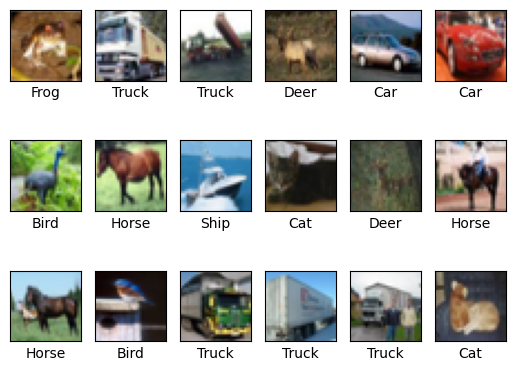

In [10]:
for i in range(18):
    plt.subplot(3,6,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(training_images[i],cmap = plt.cm.binary)
    plt.xlabel(class_names[training_labels[i][0]]) 
plt.show()   

### Data Augmentation

The model can overfit when we train on same images every epoch. It starts memorizing instead of learning.

So we use data augmentation.
We randomly rotate the image up 15 degree , shift slightly horizontally or vertically.
Also do mirroring and zooming with the below code.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(training_images)

### Building the CNN model
We keep the same padding
we use 3 convolutional layers.
After each convolutional layer we use Batch Normalization to keep the values in a stable range
Also we do dropout starting with small probability and then before output we use probability 0.5

In [12]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    #Conv layer 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #Conv layer 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #Conv layer 3
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    #No MaxPooling here — the feature maps are already small (8x8)
    layers.Dropout(0.25),

    #Fully Connected layer
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),    

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,074 (1.22 MB)

 Trainable params: 319,626 (1.22 MB)

 Non-trainable params: 448 (1.75 KB)

### Compiling the model by specifying the optimizers, loss function and metrics

In [13]:
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

### Splitting the training data into training and validation data

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    training_images, training_labels, 
    test_size=0.2,    # 20% for validation
    random_state=42
)

### Setting up callbacks

We use Early stopping and ReduceLROnPlateau

Early stopping monitors the validation loss if it does not improve for 5 consecutive epochs training stops automatically and the best weights are restored

ReduceLROnPlateau
If validation loss doesnot improve for 3 epochs, the learning rate is multiplied by 0.5. This lets the model take finer steps when it's near a good solution. Without this the model may keep overshooting the optimal weights

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

### Model training

We use the datagen.flow() which uses the augmented batches in each epochs

In [18]:
history = model.fit(
    datagen.flow(X_train,y_train, batch_size=32),
    epochs=50,
    validation_data=(X_val,y_val),
    callbacks=callbacks
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.6439 - loss: 1.0274 - val_accuracy: 0.7022 - val_loss: 0.8300 - learning_rate: 5.0000e-04
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6536 - loss: 0.9967 - val_accuracy: 0.7029 - val_loss: 0.8591 - learning_rate: 5.0000e-04
Epoch 3/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6613 - loss: 0.9898
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6608 - loss: 0.9892 - val_accuracy: 0.6589 - val_loss: 1.0138 - learning_rate: 5.0000e-04
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6721 - loss: 0.9550 - val_accuracy: 0.7459 - val_loss: 0.7190 - learning_rate: 2.5000e-04
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6758 - loss: 0.9426 - val_accuracy: 0.7365 - val_loss: 0.7444 - learning_rate: 2.5000e-04
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 

### Evaluation on testing data

In [25]:
loss, accuracy = model.evaluate(testing_images, testing_labels, verbose=0)
print(f"  Final Test Accuracy : {accuracy * 100:.2f}%")
print(f"  Final Test Loss     : {loss:.4f}")

  Final Test Accuracy : 74.84%
  Final Test Loss     : 0.7213


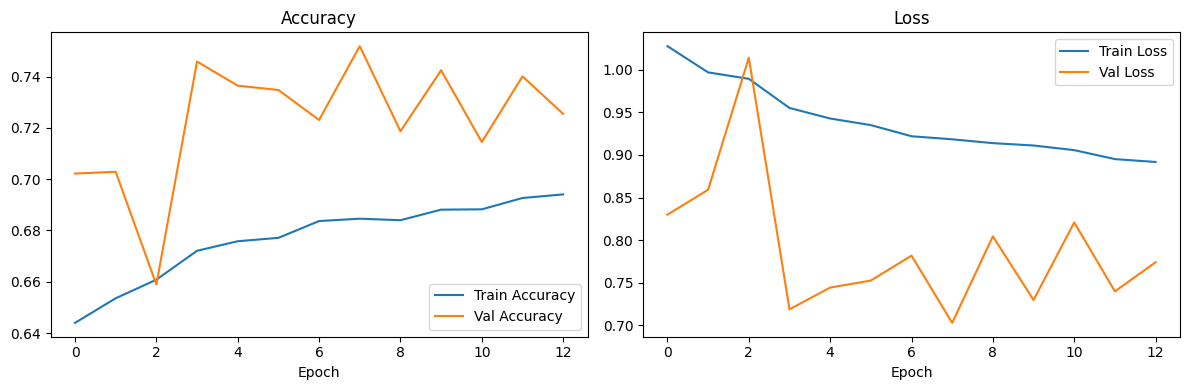

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

### Confusion matrix 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


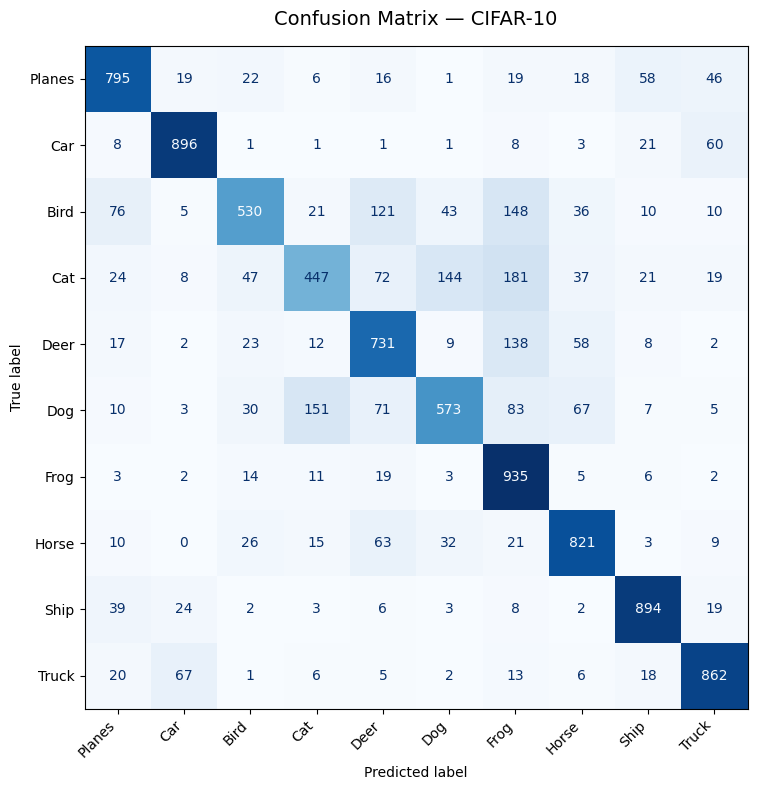

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = np.argmax(model.predict(testing_images), axis=1)
y_true = testing_labels.flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — CIFAR-10", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Testing model on random samples from the test data

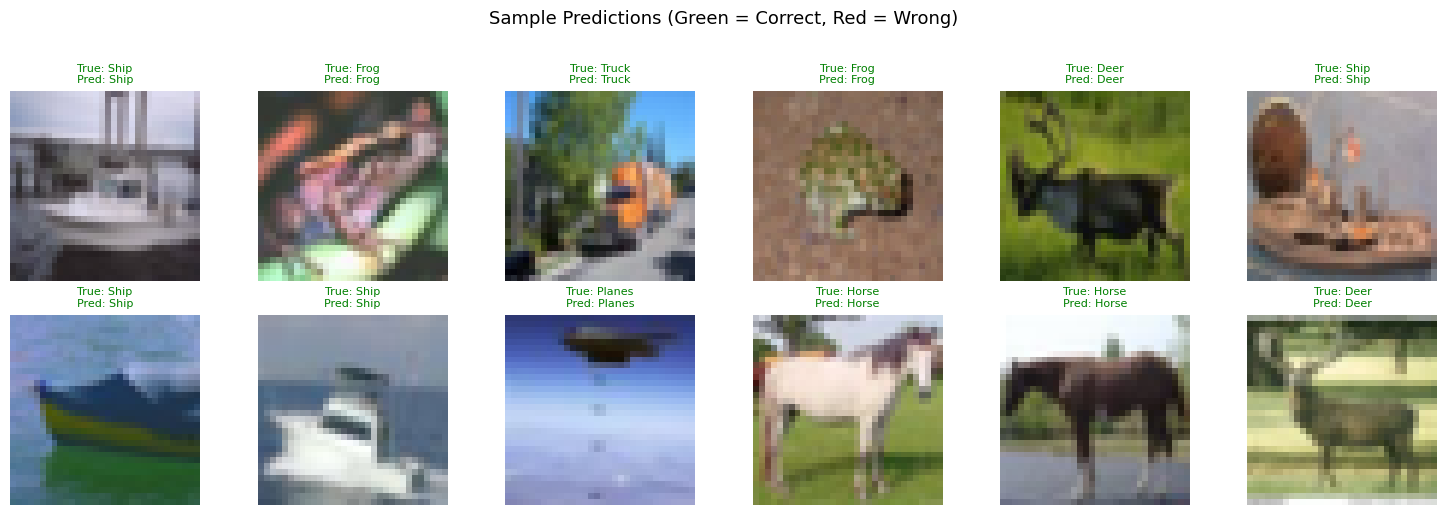

In [37]:
import random

num_samples = 12
indices = random.sample(range(len(testing_images)), num_samples)

# Batch predict instead of calling model.predict() 12 separate times
sample_images = testing_images[indices]
preds = np.argmax(model.predict(sample_images, verbose=0), axis=1)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes = axes.flatten()

for i, j in enumerate(indices):
    img    = testing_images[j]
    actual = class_names[testing_labels[j][0]]
    pred   = class_names[preds[i]]
    
    correct = actual == pred
    color   = 'green' if correct else 'red'
    
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"True: {actual}\nPred: {pred}", color=color, fontsize=8)

plt.suptitle("Sample Predictions (Green = Correct, Red = Wrong)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Classification report with respect to different classes

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      Planes       0.79      0.80      0.79      1000
         Car       0.87      0.90      0.88      1000
        Bird       0.76      0.53      0.62      1000
         Cat       0.66      0.45      0.53      1000
        Deer       0.66      0.73      0.69      1000
         Dog       0.71      0.57      0.63      1000
        Frog       0.60      0.94      0.73      1000
       Horse       0.78      0.82      0.80      1000
        Ship       0.85      0.89      0.87      1000
       Truck       0.83      0.86      0.85      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.74     10000
weighted avg       0.75      0.75      0.74     10000



# Conclusion

This project demonstrates an end-to-end image classification pipeline built on the CIFAR-10 dataset using a Convolutional Neural Network.
- Final test accuracy: **74.84%**
- The confusion matrix revealed that visually similar classes (Cat/Dog, Car/Truck) were the hardest to distinguish — an expected and explainable result

## Limitations
- 32×32 resolution makes feature extraction inherently difficult; a larger input size would likely improve accuracy
- Training data is balanced across classes; real-world datasets rarely are